In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

In [2]:
# Load the dataset
df = pd.read_excel('Concrete_Data.xls')
feature_names = df.columns[:-1]

# Train/Test Split
test_df = df.iloc[500:630]
train_df = pd.concat([df.iloc[:500], df.iloc[630:]])

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# Z-score normalization
mean_X = np.mean(X_train, axis=0)
std_X = np.std(X_train, axis=0)

X_train_std = (X_train - mean_X) / std_X
X_test_std = (X_test - mean_X) / std_X

# Log Transformation
X_train_log = np.log1p(X_train)

In [ ]:
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

def gradient_descent(X, y, learning_rate, max_iterations=10000, tolerance=1e-9):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0
    loss_history = []
    
    for i in range(max_iterations):
        predictions = np.dot(X, weights) + bias
        residuals = predictions - y
        
        # Compute gradients
        grad_weights = (2/n_samples) * np.dot(X.T, residuals)
        grad_bias = (2/n_samples) * np.sum(residuals)
        
        # Update parameters
        weights -= learning_rate * grad_weights
        bias -= learning_rate * grad_bias
        
        # Record MSE loss
        mse = np.sum(residuals**2) / n_samples
        loss_history.append(mse)
        
        if len(loss_history) > 1 and abs(loss_history[-2] - loss_history[-1]) < tolerance:
            break
            
    return weights, bias, loss_history

In [4]:
# 1. Multivariate Model (Standardized)
w_multi_std, b_multi_std, loss_multi_std = gradient_descent(X_train_std, y_train, learning_rate=0.01)
pred_train_multi_std = np.dot(X_train_std, w_multi_std) + b_multi_std
pred_test_multi_std = np.dot(X_test_std, w_multi_std) + b_multi_std

# 2. Multivariate Model (Raw)
w_multi_raw, b_multi_raw, loss_multi_raw = gradient_descent(X_train, y_train, learning_rate=1e-9, max_iterations=100000)

# 3. Univariate Model: Cement (Standardized & Raw)
cement_idx = 0 
X_train_cement_std = X_train_std[:, cement_idx].reshape(-1, 1)
w_uni_std, b_uni_std, loss_uni_std = gradient_descent(X_train_cement_std, y_train, learning_rate=0.01)

X_train_cement_raw = X_train[:, cement_idx].reshape(-1, 1)
w_uni_raw, b_uni_raw, loss_uni_raw = gradient_descent(X_train_cement_raw, y_train, learning_rate=1e-6, max_iterations=100000)

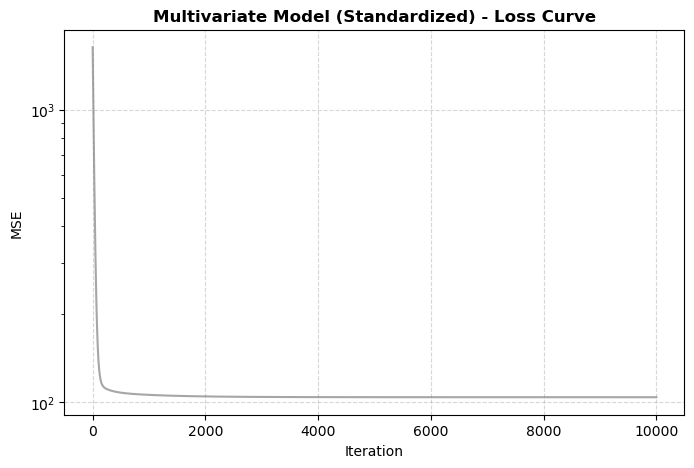

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(loss_multi_std, color='gray', alpha=0.7)
plt.title('Multivariate Model (Standardized) - Loss Curve', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

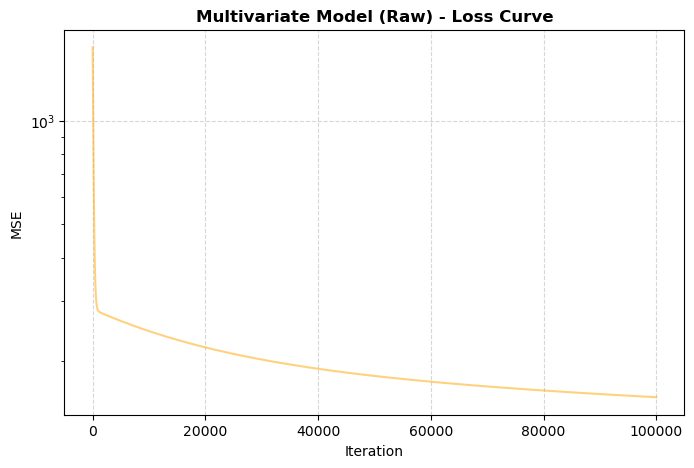

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(loss_multi_raw, color='orange', alpha=0.5)
plt.title('Multivariate Model (Raw) - Loss Curve', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

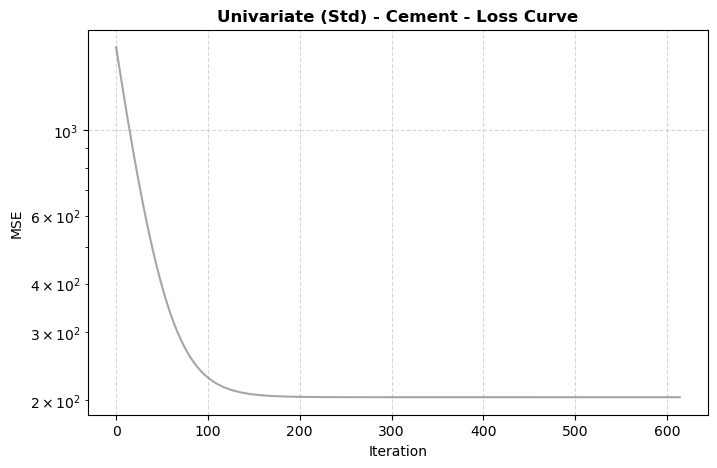

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(loss_uni_std, color='gray', alpha=0.7)
plt.title('Univariate (Std) - Cement - Loss Curve', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

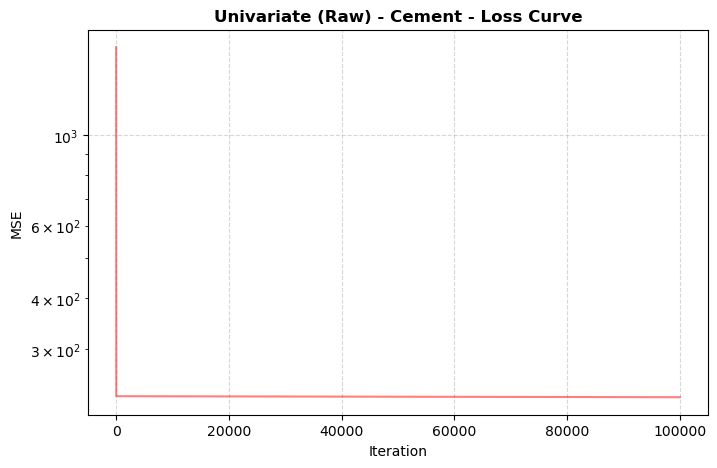

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(loss_uni_raw, color='red', alpha=0.5)
plt.title('Univariate (Raw) - Cement - Loss Curve', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [9]:
def perform_ols(X_train_data, y_train_data, feature_cols, model_name):
    X_df = pd.DataFrame(X_train_data, columns=feature_cols)
    X_with_constant = sm.add_constant(X_df)
    
    model = sm.OLS(y_train_data, X_with_constant).fit()
    print(f"\n{model_name}")
    print(f"R-squared: {model.rsquared:.4f} , Adj R-squared: {model.rsquared_adj:.4f}")
    results_df = pd.DataFrame({
        'Coefficient': model.params,
        'P-Value': model.pvalues
    })
    
    display(results_df)
    return model

In [10]:
model_std = perform_ols(X_train_std, y_train, feature_names, "OLS Results: Standardized")


OLS Results: Standardized
R-squared: 0.6240 , Adj R-squared: 0.6207


,Coefficient,P-Value
const,36.926835,0.000000e+00
Cement (component 1)(kg in a m^3 mixture),14.031875,2.492174e-40
Blast Furnace Slag (component 2)(kg in a m^3 mixture),10.480637,6.431063e-26
Fly Ash (component 3)(kg in a m^3 mixture),6.817242,3.304338e-13
Water (component 4)(kg in a m^3 mixture),-2.985807,1.790482e-03
Superplasticizer (component 5)(kg in a m^3 mixture),0.700938,2.431144e-01
Coarse Aggregate (component 6)(kg in a m^3 mixture),2.213064,5.590149e-03
Fine Aggregate (component 7)(kg in a m^3 mixture),2.769773,2.973451e-03
Age (day),7.280869,8.605349e-74


In [11]:
model_raw = perform_ols(X_train, y_train, feature_names, "OLS Results: Raw Features")


OLS Results: Raw Features
R-squared: 0.6240 , Adj R-squared: 0.6207


,Coefficient,P-Value
const,-51.429491,7.438968e-02
Cement (component 1)(kg in a m^3 mixture),0.132449,2.492174e-40
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0.124728,6.431063e-26
Fly Ash (component 3)(kg in a m^3 mixture),0.106147,3.304338e-13
Water (component 4)(kg in a m^3 mixture),-0.134100,1.790482e-03
Superplasticizer (component 5)(kg in a m^3 mixture),0.117239,2.431144e-01
Coarse Aggregate (component 6)(kg in a m^3 mixture),0.028547,5.590149e-03
Fine Aggregate (component 7)(kg in a m^3 mixture),0.033835,2.973451e-03
Age (day),0.118804,8.605349e-74


In [12]:
model_log = perform_ols(X_train_log, y_train, feature_names, "OLS Results: Log-Transformed")


OLS Results: Log-Transformed
R-squared: 0.7984 , Adj R-squared: 0.7966


,Coefficient,P-Value
const,81.001583,2.865958e-01
Cement (component 1)(kg in a m^3 mixture),23.616310,1.037662e-85
Blast Furnace Slag (component 2)(kg in a m^3 mixture),2.303370,6.960405e-36
Fly Ash (component 3)(kg in a m^3 mixture),0.196681,2.918869e-01
Water (component 4)(kg in a m^3 mixture),-38.333959,1.690141e-20
Superplasticizer (component 5)(kg in a m^3 mixture),1.873846,8.438079e-06
Coarse Aggregate (component 6)(kg in a m^3 mixture),4.193999,4.049379e-01
Fine Aggregate (component 7)(kg in a m^3 mixture),-6.646413,8.917213e-02
Age (day),9.034507,1.752847e-192


In [13]:
def perform_ols_detailed(X_train_data, y_train_data, feature_cols, model_name):
    X_df = pd.DataFrame(X_train_data, columns=feature_cols)
    X_with_constant = sm.add_constant(X_df)
    
    model = sm.OLS(y_train_data, X_with_constant).fit()
    print(f"\n {model_name}")
    display(model.summary())
    
    return model

In [14]:
model_std = perform_ols_detailed(X_train_std, y_train, feature_names, "OLS Results: Standardized")


 OLS Results: Standardized


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     184.9
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          1.92e-183
Time:                        04:18:02   Log-Likelihood:                -3367.6
No. Observations:                 900   AIC:                             6753.
Df Residuals:                     891   BIC:                             6797.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
const                                                    36.9268      0.342    108.010      0.000      36.256      37.598
Cement (component 1)(kg in a m^3 mixture)                14.0319      1.003     13.986      0.000      12.063      16.001
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    10.4806      0.964     10.867      0.000       8.588      12.373
Fly Ash (component 3)(kg in a m^3 mixture)                6.8172      0.922      7.393      0.000       5.008       8.627
Water  (component 4)(kg in a m^3 mixture)                -2.9858      0.953     -3.132      0.002      -4.857      -1.115
Superplasticizer (component 5)(kg in a m^3 mixture)       0.7009      0.600      1.168      0.243      -0.477       1.879
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      2.2131      0.797      2.778      0.006       0.649       3.777
Fine Aggregate (component 7)(kg in a m^3 mixture)         2.7698      0.930      2.979      0.003       0.945       4.595
Age (day)                                                 7.2809      0.364     20.000      0.000       6.566       7.995
==============================================================================
Omnibus:                       11.376   Durbin-Watson:                   1.244
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               11.570
Skew:                          -0.249   Prob(JB):                      0.00307
Kurtosis:                       3.247   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
model_raw = perform_ols_detailed(X_train, y_train, feature_names, "OLS Results: Raw Features")


 OLS Results: Raw Features


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     184.9
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          1.92e-183
Time:                        04:18:02   Log-Likelihood:                -3367.6
No. Observations:                 900   AIC:                             6753.
Df Residuals:                     891   BIC:                             6797.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
const                                                   -51.4295     28.791     -1.786      0.074    -107.936       5.077
Cement (component 1)(kg in a m^3 mixture)                 0.1324      0.009     13.986      0.000       0.114       0.151
Blast Furnace Slag (component 2)(kg in a m^3 mixture)     0.1247      0.011     10.867      0.000       0.102       0.147
Fly Ash (component 3)(kg in a m^3 mixture)                0.1061      0.014      7.393      0.000       0.078       0.134
Water  (component 4)(kg in a m^3 mixture)                -0.1341      0.043     -3.132      0.002      -0.218      -0.050
Superplasticizer (component 5)(kg in a m^3 mixture)       0.1172      0.100      1.168      0.243      -0.080       0.314
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0.0285      0.010      2.778      0.006       0.008       0.049
Fine Aggregate (component 7)(kg in a m^3 mixture)         0.0338      0.011      2.979      0.003       0.012       0.056
Age (day)                                                 0.1188      0.006     20.000      0.000       0.107       0.130
==============================================================================
Omnibus:                       11.376   Durbin-Watson:                   1.244
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               11.570
Skew:                          -0.249   Prob(JB):                      0.00307
Kurtosis:                       3.247   Cond. No.                     1.09e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [16]:
model_log = perform_ols_detailed(X_train_log, y_train, feature_names, "OLS Results: Log-Transformed")


 OLS Results: Log-Transformed


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     441.2
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          9.65e-304
Time:                        04:18:02   Log-Likelihood:                -3087.1
No. Observations:                 900   AIC:                             6192.
Df Residuals:                     891   BIC:                             6235.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
const                                                    81.0016     75.968      1.066      0.287     -68.096     230.099
Cement (component 1)(kg in a m^3 mixture)                23.6163      1.076     21.951      0.000      21.505      25.728
Blast Furnace Slag (component 2)(kg in a m^3 mixture)     2.3034      0.176     13.079      0.000       1.958       2.649
Fly Ash (component 3)(kg in a m^3 mixture)                0.1967      0.186      1.055      0.292      -0.169       0.563
Water  (component 4)(kg in a m^3 mixture)               -38.3340      4.030     -9.512      0.000     -46.244     -30.424
Superplasticizer (component 5)(kg in a m^3 mixture)       1.8738      0.418      4.480      0.000       1.053       2.695
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      4.1940      5.033      0.833      0.405      -5.685      14.073
Fine Aggregate (component 7)(kg in a m^3 mixture)        -6.6464      3.906     -1.702      0.089     -14.312       1.019
Age (day)                                                 9.0345      0.234     38.618      0.000       8.575       9.494
==============================================================================
Omnibus:                       16.472   Durbin-Watson:                   1.278
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.502
Skew:                           0.128   Prob(JB):                     1.76e-06
Kurtosis:                       3.800   Cond. No.                     4.04e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""